## Import the required modules

In [1]:
import matplotlib.pyplot as plt
import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from typing import Any, Dict, Callable
from QMAP_tools.qmap_inspector import QMAPInspector

In [2]:
# Not required but improved the default layout of plots
import scienceplots
plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

## Getting familiar with the database

QMAP produces two databases a "full_db" and a "agg_db" these can either be loaded using pandas/polars and contain the full data set and aggregated full dataset respectively.

```IMPORTANT: DO NOT LOAD THE FULL "full_db" AS REQUIRES ~100GB OF RAM```
Instead aim to use streaming / pre-filtering to make memory requirements manageable as shown below

In [3]:
qm = QMAPInspector()
# Load the helper class which by default has the standard relative paths of the database files so should work out of the box
# in most cases, however if the data is stored else where just use the init kwargs to set the correct path

In [4]:
qm.agg_db
# The full aggregated database can be loaded fully into memory and is constructed by aggregating a set of interesting
# statistical features of each boulder such as its area. Each boulder has a unique ID "boulder_id" (u32) which is used
# to reference the boulder especially when doing operations using both the agg_db and full_db.

boulder_id,r32_min,r32_max,r32_range,r32_mean,r32_std,r32_variance,r32_q25,r32_q75,r32_q90,r32_q95,r32_sum,r32_product,Area,center_x,min_x,max_x,center_y,min_y,max_y,center_z,min_z,max_z,number_of_samples
u32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,u32
1314079,0.008782,0.03758,0.028798,0.024304,0.008398,0.000071,0.019382,0.033284,0.034941,0.037349,0.704824,0.0,0.237382,-0.141657,-0.141737,-0.141581,0.143635,0.143574,0.143706,-0.119461,-0.119512,-0.119414,29
1413187,0.001694,0.026626,0.024932,0.016069,0.00631,0.00004,0.010922,0.021726,0.024292,0.025481,3.776242,0.0,2.586443,-0.092093,-0.092312,-0.091868,-0.132338,-0.132555,-0.132096,0.160469,0.160191,0.160735,235
393770,0.00201,0.030131,0.028121,0.018371,0.006575,0.000043,0.014488,0.023573,0.027279,0.028237,2.480025,0.0,2.604328,-0.193745,-0.193953,-0.193548,0.050954,0.050642,0.051255,-0.127992,-0.128171,-0.127819,135
2472446,0.001869,0.024637,0.022768,0.012305,0.005085,0.000026,0.008509,0.015976,0.018185,0.020838,2.584039,0.0,2.834431,0.172443,0.172277,0.172638,-0.145288,-0.145621,-0.144975,0.09436,0.094131,0.094572,210
3279109,0.023137,0.044158,0.021021,0.031739,0.005998,0.000036,0.026111,0.036744,0.03871,0.041546,0.79348,2.2726e-38,0.409576,0.194715,0.194646,0.194781,0.167516,0.167443,0.167582,0.031188,0.031092,0.031281,25
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1615029,0.000682,0.032446,0.031764,0.016798,0.007302,0.000053,0.0121,0.022756,0.025221,0.027828,2.990017,0.0,6.015429,-0.024215,-0.02465,-0.023782,-0.052792,-0.053166,-0.05246,0.233029,0.232802,0.233291,178
2527478,0.00745,0.050568,0.043118,0.028677,0.011857,0.000141,0.019959,0.037929,0.044924,0.046624,2.150801,0.0,0.899786,-0.110027,-0.110188,-0.109901,-0.165374,-0.165512,-0.165252,0.11224,0.112112,0.112384,75
1767859,0.007801,0.049634,0.041833,0.030464,0.011821,0.00014,0.021169,0.040327,0.046871,0.047996,1.218578,0.0,0.660394,-0.180355,-0.180484,-0.180223,-0.143449,-0.143575,-0.143332,-0.089675,-0.089785,-0.089569,40


In [5]:
qm.full_db.filter(pl.col("i") == 1).collect()
# The full database contains all the data needed to make the agg_db and some. It is very important that you do not try load
# the full database into memory so when previewing a standard way is to just filter by pl.col("i") == 1 which restricts the
# database to 1 / 8192 of its full size and therefore can be fully loaded into memory. We are still able to do operations
# on this dataset as you will see later leveraging the LazyFrame.

i,j,face,area,g_00800mm_spc_obj_0000n00000_v042 facet_id,g_01600mm_spc_obj_0000n00000_v042 facet_id,g_03170mm_spc_obj_0000n00000_v020 facet_id,g_06310mm_spc_obj_0000n00000_v020 facet_id,TIR detailed_survey Slope1000,TIR detailed_survey BD350,TIR detailed_survey BD440,TIR detailed_survey Ratio1000,TIR detailed_survey sigma Slope1000,TIR detailed_survey sigma BD350,TIR detailed_survey sigma BD440,TIR detailed_survey sigma Ratio1000,TIR detailed_survey facet mesh,TIR recona Slope1000,TIR recona BD350,TIR recona BD440,TIR recona Ratio1000,TIR recona sigma Slope1000,TIR recona sigma BD350,TIR recona sigma BD440,TIR recona sigma Ratio1000,TIR recona facet mesh,TIR reconb Slope1000,TIR reconb BD350,TIR reconb BD440,TIR reconb Ratio1000,TIR reconb sigma Slope1000,TIR reconb sigma BD350,TIR reconb sigma BD440,TIR reconb sigma Ratio1000,TIR reconb facet mesh,TIR reconc Slope1000,TIR reconc BD350,…,32bit_reflectance,positions_x,positions_y,positions_z,detection_lod_level,detection_lod_code,boulder_id,r32_min,r32_max,r32_range,r32_mean,r32_median,r32_std,r32_variance,r32_q25,r32_q75,r32_q90,r32_q95,r32_sum,r32_product,r32_skew,r32_kurtosis,Area,center_x,min_x,max_x,center_y,min_y,max_y,center_z,min_z,max_z,number_of_samples,g_00800mm_spc_obj_0000n00000_v042 facet_id alpha,g_01600mm_spc_obj_0000n00000_v042 facet_id alpha,g_03170mm_spc_obj_0000n00000_v020 facet_id alpha,g_06310mm_spc_obj_0000n00000_v020 facet_id alpha
u32,u32,str,f32,u64,u64,u64,u64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,…,f32,f32,f32,f32,u8,str,u32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f64,f64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,u32,u64,u64,u64,u64
1,0,"""negx""",0.000676,null,408042,null,25467,1.001857,1.002986,1.010986,null,0.000591,0.001074,0.00058,null,"""g_06310mm_spc_obj_0000n00000_v…",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,0.011107,0.138693,0.13874,-0.138707,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1085,null,17219
1,1,"""negx""",0.000681,null,408042,null,25467,1.001857,1.002986,1.010986,null,0.000591,0.001074,0.00058,null,"""g_06310mm_spc_obj_0000n00000_v…",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,0.010167,0.138667,0.138749,-0.138711,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1085,null,17219
1,2,"""negx""",0.000654,null,408042,null,25467,1.001857,1.002986,1.010986,null,0.000591,0.001074,0.00058,null,"""g_06310mm_spc_obj_0000n00000_v…",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,0.011566,0.138643,0.138756,-0.138716,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1085,null,17219
1,3,"""negx""",0.000647,null,408042,null,25467,1.001857,1.002986,1.010986,null,0.000591,0.001074,0.00058,null,"""g_06310mm_spc_obj_0000n00000_v…",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,0.012794,0.138617,0.138762,-0.138724,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1085,null,17219
1,4,"""negx""",0.000632,null,408042,null,25467,1.001857,1.002986,1.010986,null,0.000591,0.001074,0.00058,null,"""g_06310mm_spc_obj_0000n00000_v…",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,0.012029,0.138591,0.138768,-0.138733,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1085,null,17219
…,…,…,…,…,…,…,…,…,…,…

## Hist example 1 : Simple plotting a 1D histogram

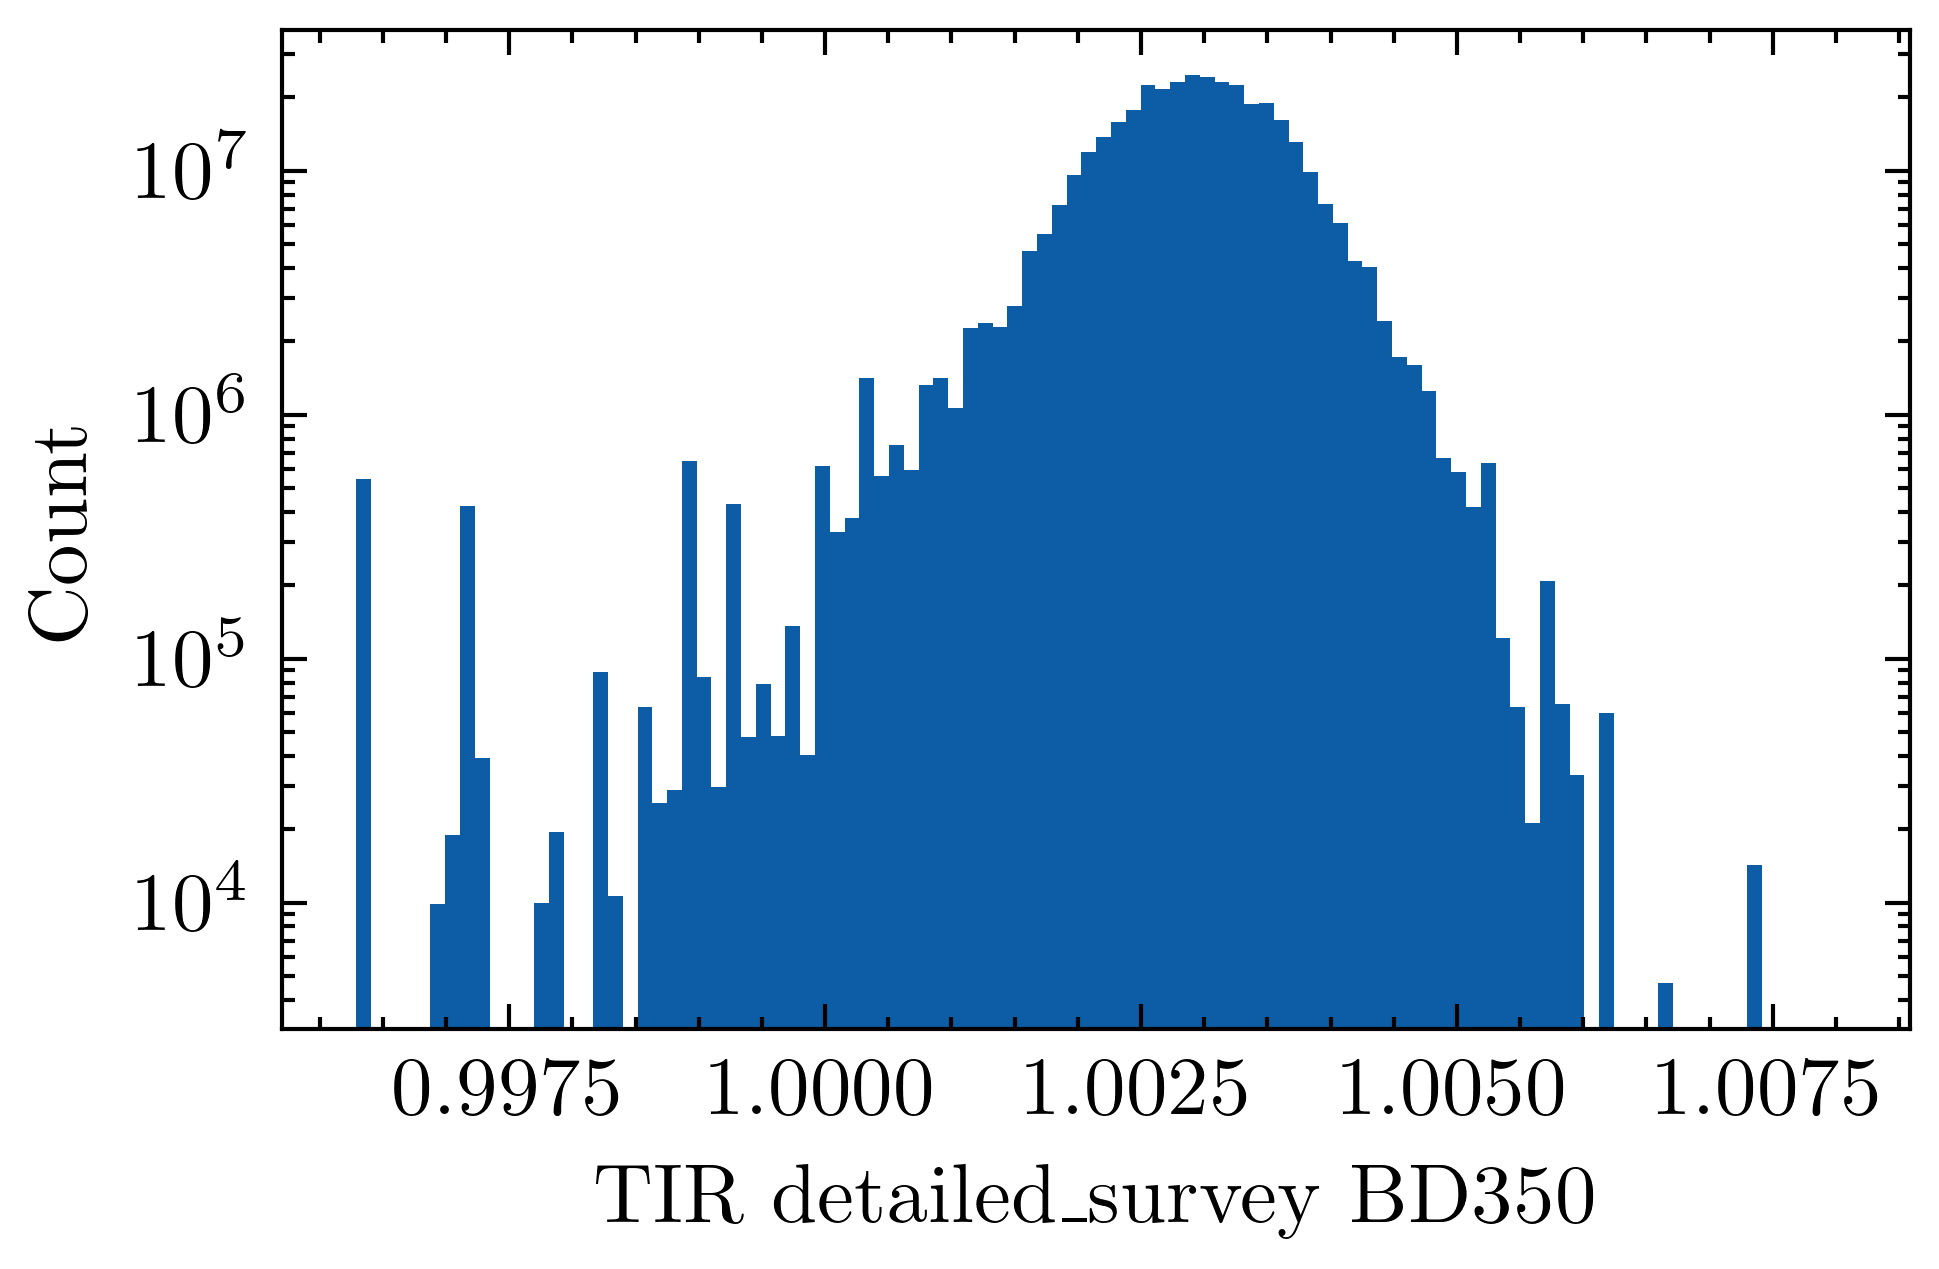

In [6]:
# Define the item we will be plotting
item = "TIR detailed_survey BD350"

# Find the range from the database
range = qm.get_column_extrema(item)

# Get the counts and bins for a linear binned hist (custom LazyFrame can be used if entered in the kwarg)
counts, bins = qm.get_column_hist(
    column = item,
    bin_range = range,
    bin_number = 100
)

# Plot the histogram data
plt.bar(
    bins[:-1],
    counts,
    width=np.diff(bins),
    align="edge",
)

plt.yscale("log")
plt.xlabel(item)
plt.ylabel("Count")
plt.show()

## Hist example 2 : Custom filtering a 1D histogram

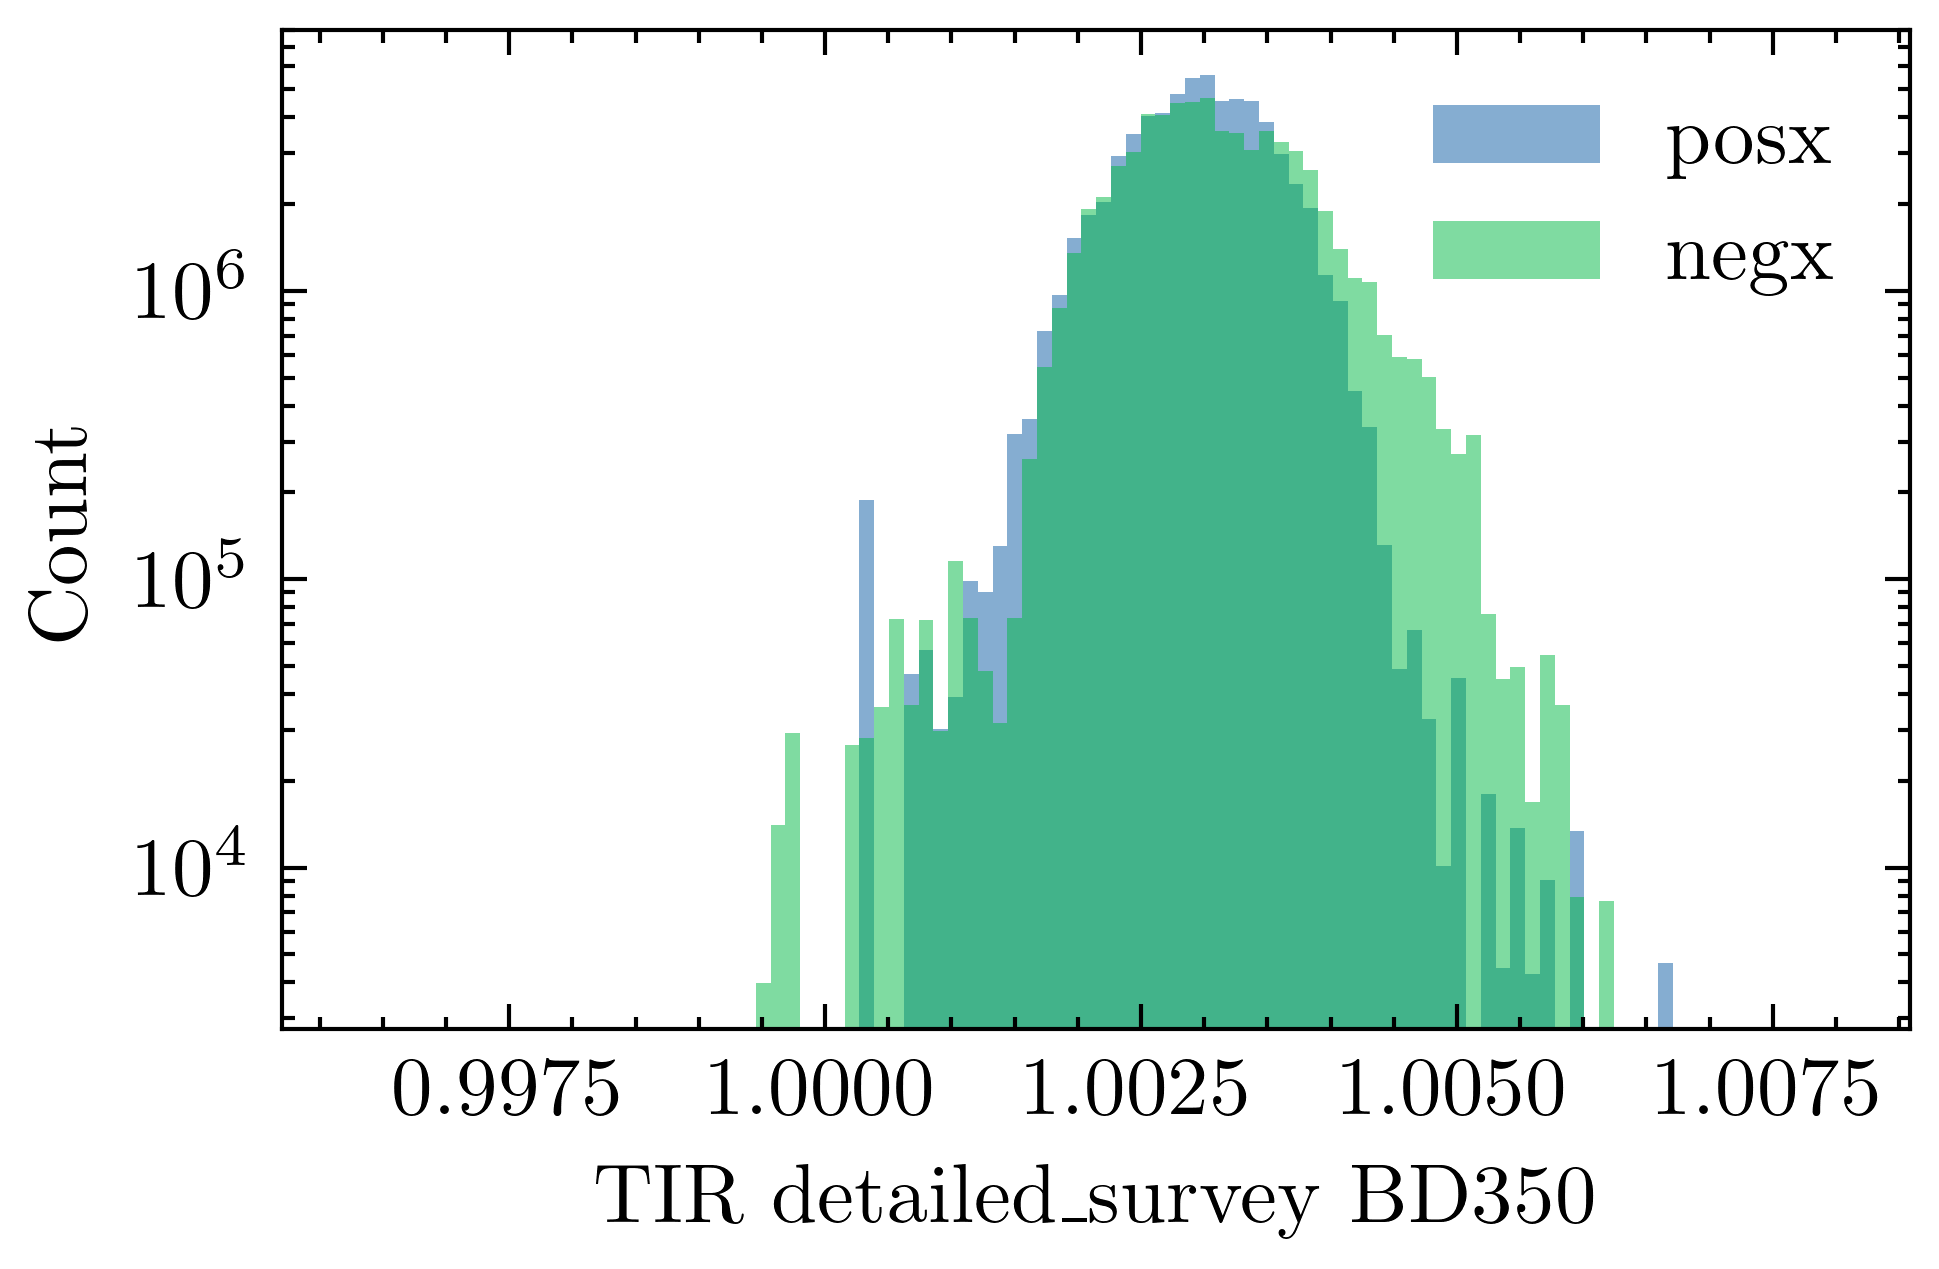

In [7]:
# Define the item we will be plotting
item = "TIR detailed_survey BD350"

# Find the range from the database
range = qm.get_column_extrema(item)

# We will filter by face
for face in ["posx", "negx"]:
    # Get the counts and bins for a linear binned hist (custom LazyFrame can be used if entered in the kwarg)
    counts, bins = qm.get_column_hist(
        column = item,
        bin_range = range,
        bin_number = 100,
        custom_lf=qm.full_db.filter(pl.col("face") == face)
    )

    # Plot the histogram data
    plt.bar(
        bins[:-1],
        counts,
        width=np.diff(bins),
        align="edge",
        label = face,
        alpha = 0.5 # So can see both hists
    )

plt.yscale("log")
plt.xlabel(item)
plt.ylabel("Count")
plt.legend()
plt.show()

## Hist example 3 : Simple 2D histogram

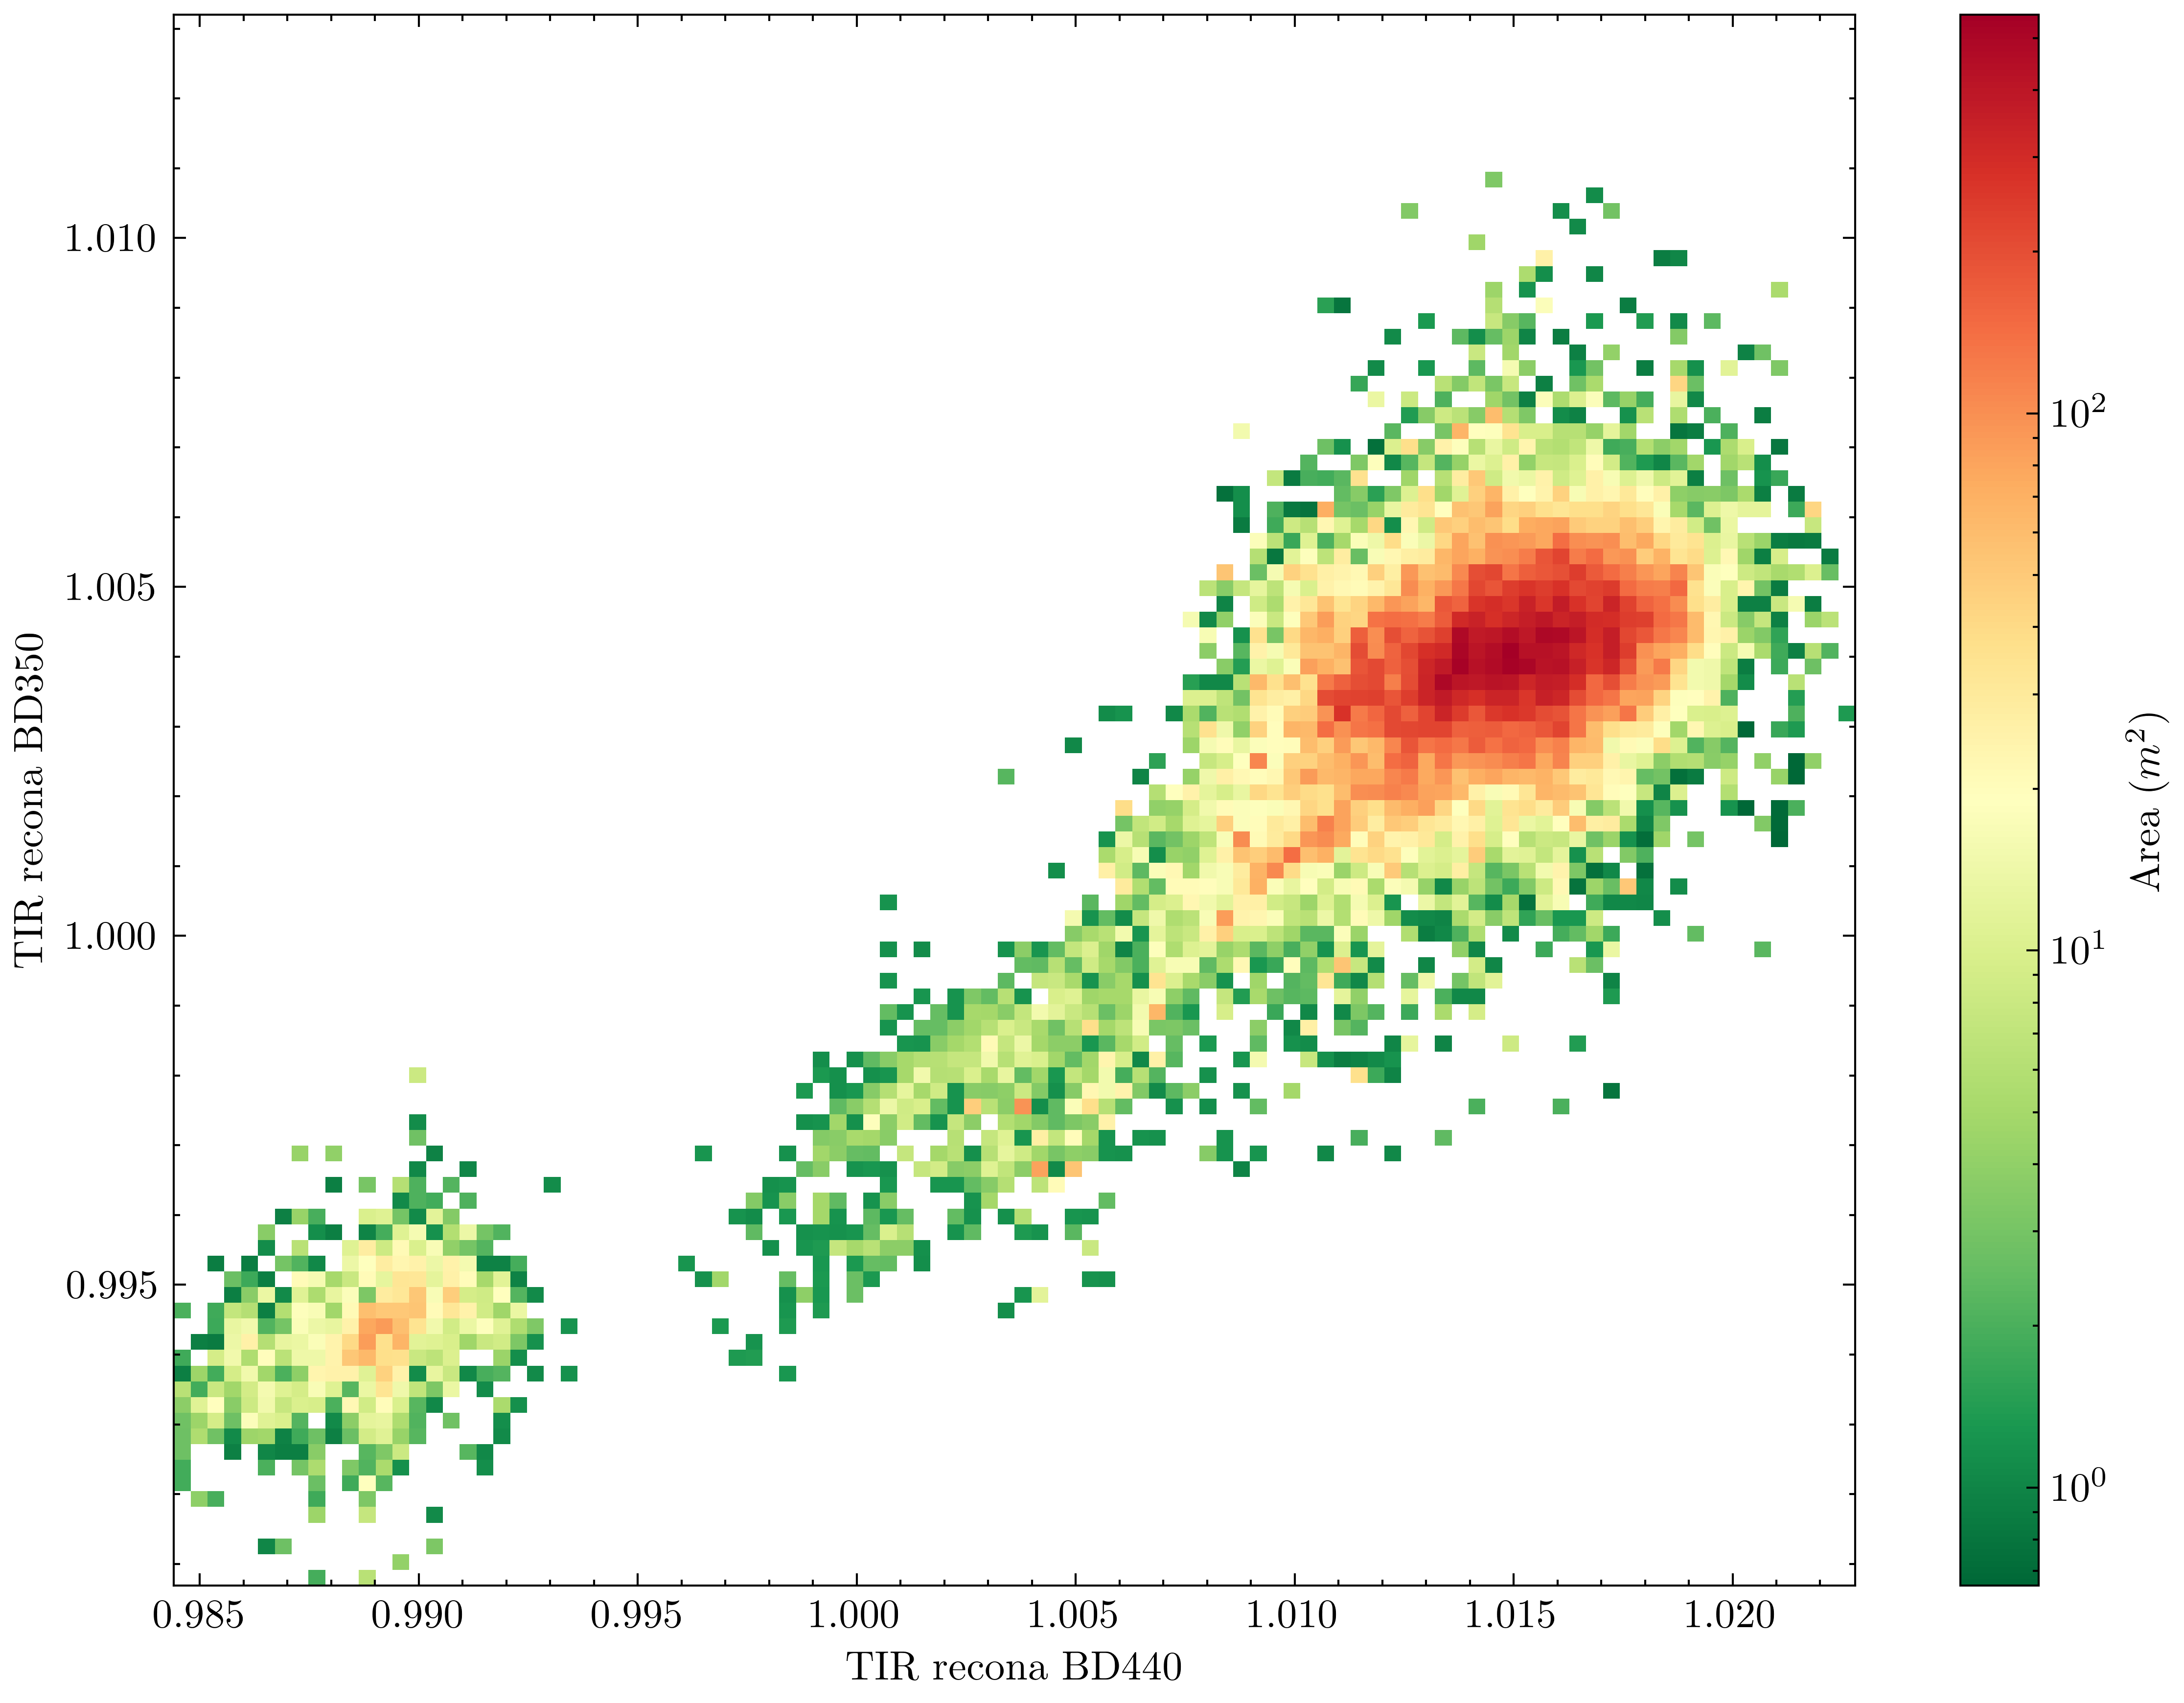

In [8]:
from matplotlib import colors

# Define your items
x_item, y_item = "TIR recona BD440", "TIR recona BD350"

# Get the hist data (will be weighted by the row area by default can edit using the weight_col)
counts, x_edges, y_edges = qm.get_column_hist2d(
    columns=(x_item, y_item),
    bin_ranges=(
        qm.get_column_extrema(x_item), 
        qm.get_column_extrema(y_item)
        ),
    bin_numbers=(100, 100)
)

plt.figure(figsize=(8, 6))

plt.pcolormesh(
    x_edges,
    y_edges,
    counts.T,        # transpose because pcolormesh expects (y, x)
    shading="auto",
    cmap="RdYlGn_r",
    norm = colors.LogNorm()
)

plt.xlabel(x_item)
plt.ylabel(y_item)
plt.colorbar(label = r"Area ($m^2$)")
plt.tight_layout()
plt.show()